**Importar librerias Necesarias**

In [190]:
from sklearn.datasets import load_iris
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

**Cargar Datos**

In [191]:
iris = load_iris()

x = iris.data
y = iris.target

print(x.shape)
print(y.shape)

(150, 4)
(150,)


In [192]:
print(iris.feature_names)
print(iris.target_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
['setosa' 'versicolor' 'virginica']


**Dividir Datos**

In [193]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

#**Decision Tree**

In [194]:
def gini(y):  #medida de impureza

  clases, cantidad = np.unique(y, return_counts=True)
  proporcion = cantidad/len(y)

  gini = 1 - np.sum(proporcion**2)

  return gini


In [195]:
def decision(x, y, feature, threshold):  #criterio de decision

  left = x[:, feature] <= threshold
  right = ~left #van a la derecha los que no cumplan la condicion para ir a la izquierda

  return x[left], y[left], x[right], y[right]

In [196]:
def gini_division(y_left, y_right):  #calcula el gini ponderado después de la division    (algoritmo de entrenamiento)

  m = len(y_left) + len(y_right)
  m_left = len(y_left)
  m_right = len(y_right)

  peso_left = (m_left / m)
  peso_right = (m_right / m)

  gini_division = peso_left * gini(y_left) + peso_right * gini(y_right)

  return gini_division


In [197]:
def mejor_division(x_train, y_train):   #buscar la mejor division para un nodo
                                        #el nodo raiz contiene la mejor división entre todas las divisiones posibles sobre el conjunto de entrenamiento
  mejor_j = float("inf")
  mejor_feature = None
  mejor_threshold = None

  for feature in range(x_train.shape[1]):
    thresholds = np.unique(x_train[:, feature])
    for threshold in thresholds:
      x_left, y_left, x_right, y_right = decision(x_train, y_train, feature, threshold)
      j = gini_division(y_left, y_right)
      if j < mejor_j:
        mejor_j = j
        mejor_feature = feature
        mejor_threshold = threshold

  return mejor_feature, mejor_threshold, mejor_j


In [198]:
#prueba y visualizacion de lo que devuelve la función (la mejor division)
feature, threshold, score = mejor_division(x_train, y_train)

print("Feature:", feature)
print("Threshold:", threshold)
print("Gini division:", score)

Feature: 2
Threshold: 1.9
Gini division: 0.3333333333333333


In [199]:
class node():  #crear la clase nodo
              #establecer las conexiones de un nodo con los otros y si es hoja (leaf) asignarle un valor

  def __init__(
        self, feature=None,
        threshold=None,
        left=None,
        right=None,
        valor=None ):

    self.feature = feature
    self.threshold = threshold

    self.left = left
    self.right = right

    self.valor = valor


In [200]:
def clase_hoja(y): #definir la etiqueta (clase) que tendra la hoja de acuerdo a la clase con más etiquetas presentes
  clases, cantidad = np.unique(y, return_counts=True)
  clase = clases[np.argmax(cantidad)]
  return clase

In [201]:
def decision_tree(x, y, profundidad=0, max_depth=3):

  if len(np.unique(y)) == 1:  #si todas las muestras del nodo pertenecen a la misma clase
    return node(valor = y[0])  #y[0] -> todos los elementos de y tienen la misma clase

  if profundidad >= max_depth: #si se llega a la profundidad maxima se calcula la clase de ese nodo y se vuelve hoja
    return node(valor = clase_hoja(y))

  feature, threshold, score_j = mejor_division(x, y)  #se busca la mejor división

  if feature is None:
    return node(valor = clase_hoja(y))  #si no hay una división válida, crear una hoja

  x_left, y_left, x_right, y_right = decision(x, y, feature, threshold)   #se decide que valores van a que lado de acuerdo a la condicion encontrada en mejor_division

  left = decision_tree(x_left, y_left, profundidad + 1, max_depth)    #se repite el proceso para los datos que fueron a la izquierda y derecha
  right = decision_tree(x_right, y_right, profundidad + 1, max_depth)  #asi se crea un "arbol" recursivamente

  return node(feature = feature,     #guarda los datos del nodo actual (conecta con los nodos hijos)
              threshold = threshold,
              left = left,
              right = right)


In [202]:
#crear el arbol
arbol = decision_tree(x_train, y_train, max_depth=3)

In [203]:
def predict_one(x, nodo):   #predice la clase de una sola muestra (recorre el "arbol")

  if nodo.valor is not None: #si es una hoja devuelve la clase almacenada
    return nodo.valor

  if x[nodo.feature] <= nodo.threshold:  #si x en la caracteristica que guardó el nodo es menor al treshold que guardó
    return predict_one(x, nodo.left)   #sigue al nodo izquierdo

  else:
    return predict_one(x, nodo.right)  #si no sigue al nodo derecho


In [204]:
def predict(x, arbol): #el "arbol" guarda el nodo raiz (el return lo devuelve)
    return np.array([predict_one(row, arbol)for row in x]) #recorre todas las muestras y predice una por una

In [205]:
y_pred = predict(x_test, arbol)
print(y_pred)

[0 2 1 1 0 1 0 0 2 1 2 2 2 1 0 0 0 1 1 2 0 2 1 2 2 2 1 0 2 0]


In [206]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9666666666666667


#**Comparación con sklearn**

In [210]:
from sklearn.tree import DecisionTreeClassifier

modelo = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42)

modelo.fit(x_train, y_train)

y_pred_sklearn = modelo.predict(x_test)

accuracy_sklearn = accuracy_score(
    y_test,
    y_pred_sklearn)

print("Implementación paso a paso:", accuracy)
print("Sklearn:", accuracy_sklearn)

Implementación paso a paso: 0.9666666666666667
Sklearn: 0.9666666666666667


**Comparacón Matriz de Confusión:**

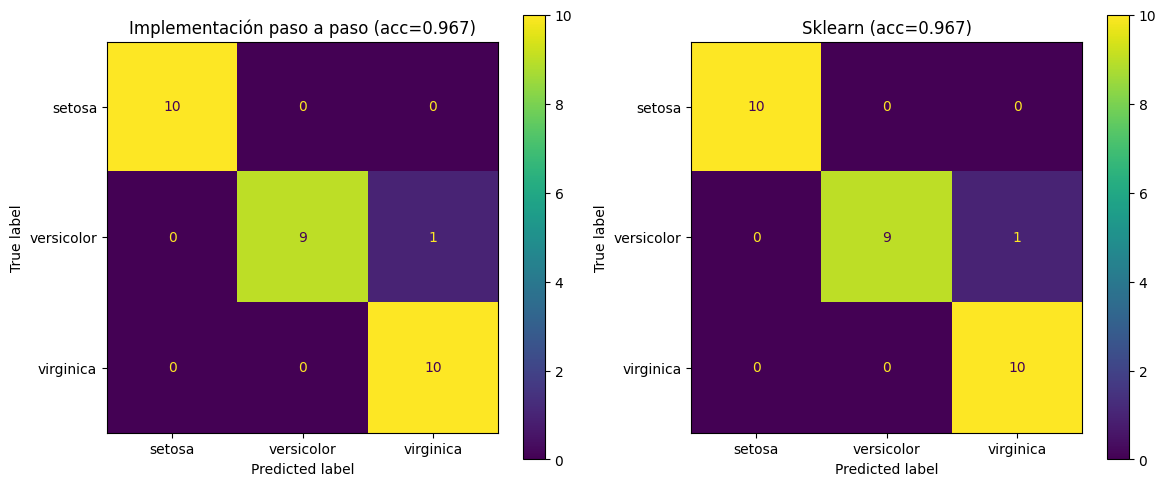

In [209]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=iris.target_names,
    cmap="viridis",
    ax=axes[0])
axes[0].set_title(f"Implementación paso a paso (acc={accuracy:.3f})")

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_sklearn,
    display_labels=iris.target_names,
    cmap="viridis",
    ax=axes[1])
axes[1].set_title(f"Sklearn (acc={accuracy_sklearn:.3f})")

plt.tight_layout()
plt.show()